# `hw2`: Inference of Oxygen Saturation from Photoplethysmography


Deadline: **Monday, November 25, 11:59 PM**. 
- Submit your completed notebook on your personal Github repository created when accepting the assignment.
- All cells must be executable and their outputs should not be erased before submission.
- Homeworks are carried out *individually*.

In [ ]:
# Fill in this cell with your personal details:
# - Name: Dutailly Alexandre 
# - Student ID: S195855
# - Email: alexandre.dutailly@student.uliège.be

In this homework, you will have to infer oxygen saturation (SPO2 / SO2) measures from unprocessed photoplethysmography (PPG) using data from the [OpenOximetry Repository](https://physionet.org/content/openox-repo/1.0.1). You will build a small probabilistic model of PPG from SpO2, and infer some physical parameters along with the unknown SpO2 from the observed PPG data. See Homework 1 for instructions on how to handle the dataset.

# Oximeter

An [oximeter](https://en.wikipedia.org/wiki/Pulse_oximetry) is a medical device that you might have seen clipped onto someone's fingertip at a hospital. It estimates **blood oxygen saturation** ($\text{SpO}_2$) by shining light through the skin at two different wavelengths (red at $\lambda = 66 \text{ nm}$ and infrared at $\lambda = 940 \text{ nm}$) and measuring how much light passes through. This measurement technique produces two [photoplethysmographs](https://en.wikipedia.org/wiki/Photoplethysmogram) (PPG signals) - one for each wavelength.

PPG is a non-invasive method that measures changes in blood volume in tissue using light. When your heart beats, the volume of blood in your vessels changes, which affects how much light is absorbed or reflected by the tissue. Think of it like shining a flashlight through your finger - the amount of light that passes through changes slightly with each heartbeat.

The oxygen saturation ($\text{SpO}_2$) represents the percentage of hemoglobin (the protein in red blood cells that carries oxygen) that is carrying oxygen. Mathematically, it's defined as
$$
    \text{SpO}_2 = \frac{[\text{HbO}_2]}{[\text{HbO}_2] + [\text{Hb}]},
$$
where $[\text{HbO}_2]$ is the concentration of oxygenated hemoglobin and $[\text{Hb}]$ is the concentration of deoxygenated hemoglobin. A healthy person typically has $\text{SpO}_2$ levels between 95-100%.

The PPG signal has two main components:
1. The **pulsative component** (AC) represents the changing part of the signal that varies with each heartbeat;
2. The **non-pulsative component** (DC) represents the relatively constant background signal.

Think of this like waves on the ocean: AC is like the waves on the surface, while DC is like the ocean's depth. For a cardiac cycle from time $t_1$ to $t_2$, these components are defined as
$$
    \text{AC}(\lambda) = \max(\text{PPG}(\lambda)_{t_1:t_2}) - \min(\text{PPG}(\lambda)_{t_1:t_2})
$$
$$
    \text{DC}(\lambda) = \text{mean}(\text{PPG}(\lambda)_{t_1:t_2})
$$

Since many factors can affect how light passes through tissue (like skin color, thickness, or even the presence of nail polish), oximeters use a ratio ($R$) that helps cancel out these interfering factors. This ratio compares the pulsative components at both wavelengths, normalized by their respective non-pulsative components:

$$
    R
    =
    \frac{
        \text{AC}(660 \text{ nm})/\text{DC}(660 \text{ nm})
    }{
        \text{AC}(940 \text{ nm})/\text{DC}(940 \text{ nm})
    }
$$

This ratio $R$ has a known relationship with $\text{SpO}_2$, which allows us to estimate oxygen levels without drawing blood. The different absorption patterns of oxygenated and deoxygenated hemoglobin at these two wavelengths make this estimation possible.

## Probabilistic Model

In this homework, we will build a probabilistic model that relates oxygen saturation ($\text{SpO}_2$) to the observed ratio ($R$) through five parameters:
- $\sigma^2$: variance parameter capturing measurement uncertainty,
- $\epsilon_{\text{HbO}_2}(660 \text{ nm})$: absorption coefficient of oxygenated hemoglobin at red light,
- $\epsilon_{\text{Hb}}(660 \text{ nm})$: absorption coefficient of deoxygenated hemoglobin at red light,
- $\epsilon_{\text{HbO}_2}(940 \text{ nm})$: absorption coefficient of oxygenated hemoglobin at infrared light,
- $\epsilon_{\text{Hb}}(940 \text{ nm})$: absorption coefficient of deoxygenated hemoglobin at infrared light.

Our model is based on the Beer-Lambert law, a fundamental principle in spectroscopy. This law states that the absorption of light by a substance in solution is proportional to its concentration. For blood at a given wavelength $\lambda$, we can write
$$
    A(\lambda) = \text{SpO}_2 \; \epsilon_{\text{HbO}_2}(\lambda) + (1 - \text{SpO}_2) \; \epsilon_{\text{Hb}}(\lambda).
$$

This equation tells us that the total absorption is a weighted average of the absorption by oxygenated and deoxygenated hemoglobin, where the weights are determined by the oxygen saturation level.

We then assume that the ratio ($R$) of normalized pulsative signals is proportional to the ratio of absorptions at the two wavelengths. To account for measurement noise and other sources of uncertainty, we model $R$ as following a Normal distribution. That is, 
$$
    R
    \sim
    \mathcal{N}\left(
        \frac{
            \text{SpO}_2 \; \epsilon_{\text{HbO}_2}(660 \text{ nm}) + (1 - \text{SpO}_2) \; \epsilon_{\text{Hb}}(660 \text{ nm})
        }{
            \text{SpO}_2 \; \epsilon_{\text{HbO}_2}(940 \text{ nm}) + (1 - \text{SpO}_2) \; \epsilon_{\text{Hb}}(940 \text{ nm})
        },
        \sigma^2
    \right).
$$

In this model, both the input ($\text{SpO}_2$) and the five parameters are unknown and need to be estimated from the data. However, we report below some empirical values for the absorption coefficients that should help you set reasonable priors for these parameters. Further reference values can be found at [omlc.org/spectra/hemoglobin/summary.html](https://omlc.org/spectra/hemoglobin/summary.html).

<div class="alert alert-info">
    
**Information**. We provide the functions `extract_beats` and some empirical absorption coefficients.
    
</div>

In [1]:
import os
import emcee
import corner
import warnings
import wfdb as wf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.stats import norm, gamma
from scipy.signal import butter, filtfilt, resample, find_peaks

warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
EPS_HBO2_660 = 319.6
EPS_HB_660 = 3226.56

EPS_HBO2_940 = 1214
EPS_HB_940 = 693.44

In [3]:
def extract_beats(ppg, f_ppg, min_time_between=0.4):
    """
    Arguments:
    ----------
    ppg: np.ndarray
        A one dimensional time series of ppg data (red or ir).
    f_ppg: int
        The sampling frequency (Hz).
    min_time_between: float
        The minimal time between two heartbeats.

    Returns:
    --------
    - peaks: np.ndarray
        The indices of the heartbeats peaks in the ppg time series.
    """
    min_number_between = int(min_time_between * f_ppg)
    peaks, _ = find_peaks(ppg, distance=min_number_between)
    return peaks

# Exercises

- Solve the exercises below by making the best use of the API offered in the imported libraries.
- You will also need to use the `wfdb` library for reading and writing waveform data (see [WFDB Documentation](https://wfdb.readthedocs.io/en/latest/wfdb.html)).
- For plots, feel free to use `matplotlib`, `seaborn` or `pandas` built-in plotting functions.
- Follow the data visualization principles as best as possible to make your plots effective and readable.
- For each exercise, add Markdown cells to explain what you are doing and to discuss your results.

<div class="alert alert-info">
    
**Information**. In this homework, we focus on encounter `c5dd95c1ac9fc618cab2e940096089c6a91be58206fa6fc6a1375c69c4922779`. Below, we load the SpO2 data from `f'{encounter_id}_2hz.csv'` (device 59) and the PPG data from `f'{encounter_id}_ppg.dat'`. 
    
</div>

<div class="alert alert-danger">

**Warning**. Note that the PPG recording starts approximately 2.80 min after the SpO2, and it is shifted accordingly.

</div>

In [4]:
encounter_id = "c5dd95c1ac9fc618cab2e940096089c6a91be58206fa6fc6a1375c69c4922779"

In [5]:
f_spo2 = 2

start = 5 * 60

saturation = pd.read_csv(f'data/waveforms/{encounter_id[0]}/{encounter_id}_2hz.csv')
spo2 = saturation['dev59_SpO2'].to_numpy()[start * f_spo2:]
t_spo2 = np.arange(spo2.shape[0]) / (60 * f_spo2)

In [6]:
f_ppg = 86

start = (5 - 2.8) * 60

ppg, ppg_info = wf.rdsamp(f'data/waveforms/{encounter_id[0]}/{encounter_id}_ppg')
print(ppg_info)
ppg = ppg[int(start * f_ppg):]

ir = ppg[:, 0]
red = ppg[:, 1]
t_ppg = np.arange(len(red)) / (60 * f_ppg)

{'fs': 86, 'sig_len': 263475, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['counts', 'counts'], 'sig_name': ['IR', 'RED'], 'comments': ['PPG IR LED', 'PPG RED LED']}


## Part 1: Data Preparation

<div class="alert alert-success">

**Exercise**. Display the SpO2 data along with the red and infrared PPG data on a single figure.

</div>

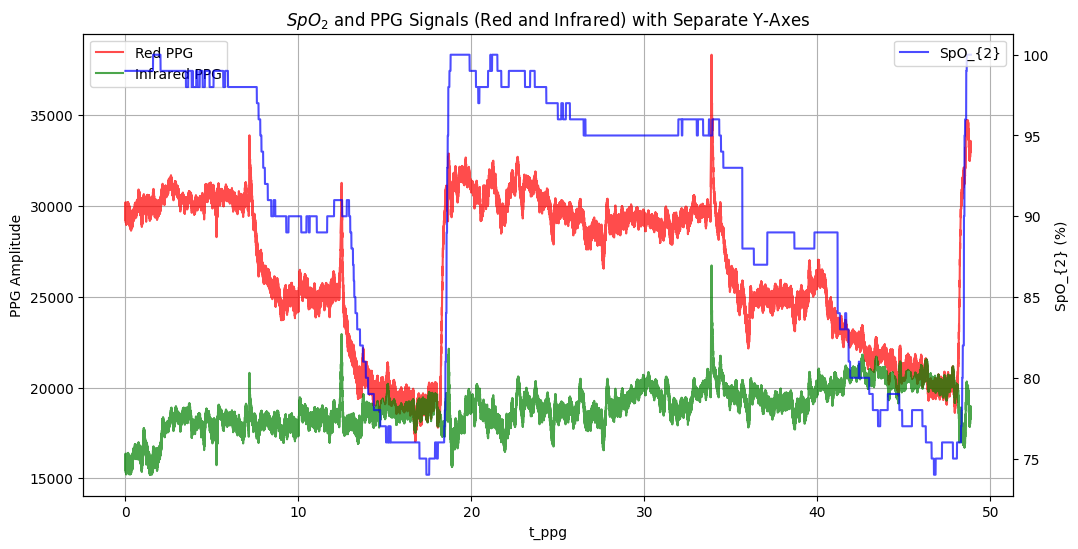

In [8]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(t_ppg, red, label="Red PPG", color='red', alpha=0.7)
ax1.plot(t_ppg, ir, label="Infrared PPG", color='green', alpha=0.7)
ax1.set_xlabel("t_ppg")
ax1.set_ylabel("PPG Amplitude")
ax1.legend(loc="upper left")
ax1.grid(True)

# Create a secondary y-axis for SpO
ax2 = ax1.twinx()
ax2.plot(t_spo2, spo2, label="SpO_{2}", color='blue', alpha=0.7)
ax2.set_ylabel("SpO_{2} (%)")
ax2.legend(loc="upper right")


plt.title("$SpO_{2}$ and PPG Signals (Red and Infrared) with Separate Y-Axes")
plt.show()

We plot the red and infrared PPG signals on the same time axis (`t_ppg`) and the $SpO_{2}$ on a secondary vertical axis. The plot shows that the red signal faithfully follows the $SpO_{2}$ curve (synchronised rises and falls), while the infrared, which is noisier, remains legible thanks to its peaks coinciding with those of the red.

- PPG records the variations in light caused by the heartbeat.  
- Pulse oximetry compares the absorption of blood at two wavelengths (red and infrared) to deduce the oxygen content.  
- The ratio between these two signals is then converted into a percentage of $SpO_{2}$.


<div class="alert alert-success">
    
**Exercise**. Using the function `extract_beats`, find all starts of cardiac cycles (the peak of the heart beat) $t_1, t_2, \dots, t_N$ using one of the two PPG signals (red or infrared). Then, select a random heart cycle, defined by its span $[t_k:t_{k+1}]$, and display both PPG time series $\text{PPG}(\lambda)_{t_k:t_{k+1}}$ during that heart cycle. Finally, display the distribution of the PPG time series over all heart cycles (or a subsample of a all heart cycles). 
    
</div>

<div class="alert alert-info">

**Hint**. You may want to remove the nonpulsative component $\text{DC}(\lambda)_{k}$ of the each time series $\text{PPG}(\lambda)_{t_k:t_{k+1}}$ for displaying the distribution.

</div>

Nombre de battements détectés red: 4291
Nombre de battements détectés ir: 4317


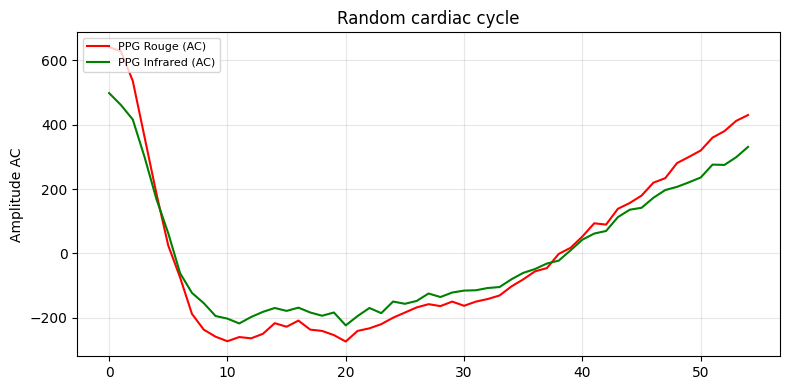

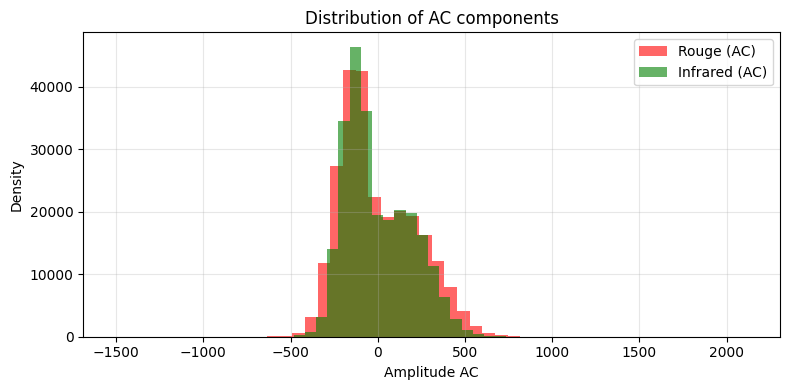

In [9]:
beats = extract_beats(red, f_ppg=f_ppg, min_time_between=0.4)
beats1 = extract_beats(ir, f_ppg=f_ppg, min_time_between=0.4)
print(f"Nombre de battements détectés red: {len(beats)}")
print(f"Nombre de battements détectés ir: {len(beats1)}")

ac_red, dc_red, ac_ir, dc_ir = [], [], [], []
ac_r, ac_i = [], []
seg_i, seg_r = [], []
seg_r.append(red[:beats[0]])
seg_i.append(ir [:beats[0]])


for i in range(len(beats) - 1):
    a, b = beats[i], beats[i + 1]
    seg_r.append(red[a:b])
    seg_i.append(ir [a:b])

for r_seg, i_seg in zip(seg_r, seg_i):
    ac_red.append(r_seg.max() - r_seg.min())
    dc_red.append(r_seg.mean())
    ac_ir.append(i_seg.max() - i_seg.min())
    dc_ir.append(i_seg.mean())

    ac_r.append(r_seg - r_seg.mean())
    ac_i.append(i_seg - i_seg.mean())



k = np.random.randint(0, len(ac_r))
a, b = beats[k], beats[k+1]
t_cycle = np.arange(a, b) / f_ppg

plt.figure(figsize=(8,4))
plt.plot(ac_r[k], label="PPG Rouge (AC)",color='red')
plt.plot(ac_i[k], label="PPG Infrared (AC)", color='green')
plt.xlabel("")
plt.ylabel("Amplitude AC")
plt.title("Random cardiac cycle")
plt.legend(loc="upper left", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


all_red_ac = np.hstack(ac_r)
all_ir_ac = np.hstack(ac_i)

plt.figure(figsize=(8,4))
plt.hist(all_red_ac, bins=50, alpha=0.6, label="Rouge (AC)", color='red')
plt.hist(all_ir_ac, bins=50, alpha=0.6, label="Infrared (AC)", color='green')
plt.xlabel("Amplitude AC")
plt.ylabel("Density")
plt.title("Distribution of AC components")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


We first detect the beginnings of each heartbeat in the red and infrared signals.  
We then extract a random cycle, centre its values to keep only the pulsatile variation (AC) and display it. We see a dip followed by a rise, almost identical for both wavelengths.  

We then repeat this operation on all the cycles to compile their AC components and plot the histogram. 
So both signals rise and fall at the same time with each beat, but the red signal shows a little more variation.


<div class="alert alert-success">
    
**Exercise**. For both PPG signals, compute the pulsative component ($\text{AC}(\lambda)$) and non pulsative component ($\text{DC}(\lambda)$) for each heart cycle. Then, compute the ratio $R$ of normalized pulsative components. 

You now have $N$ ratios (one for each cardiac cycle), and $M$ saturation measurements (one every 0.5 second). Resample the ratio $R$ at the same times as the $\text{SpO2}$ time series so that the two time series are paired.
    
</div>

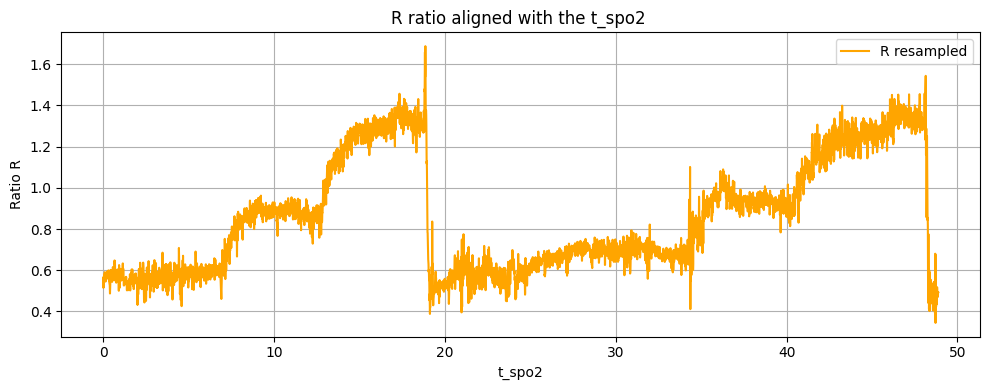

In [10]:
R = (np.array(ac_red)/np.array(dc_red)) / (np.array(ac_ir)/np.array(dc_ir))
R_resampled = resample(R, len(spo2)) 
t_spo2 = np.arange(len(spo2)) * (0.5/60) 

plt.figure(figsize=(10,4))
plt.plot(t_spo2, R_resampled, color='orange', label='R resampled')
plt.xlabel("t_spo2")
plt.ylabel("Ratio R")
plt.title("R ratio aligned with the t_spo2 ")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


We repeat the loop in the same way as we did for the previous exercise, except that we calculate **AC** and **DC** and then calculate the ratio given in the statement. Then we apply the resample function to this ratio, which adapts the size of the ration signal to the length of the $SpO_{2}$ signal. We obtain the signal in the following plot.

<div class="alert alert-success">

**Exercise**. Display the SpO2 data along with the infered SpO2 data using the empirical law $\text{SpO2} = 110 - 25 R$. Discuss the results.

</div>

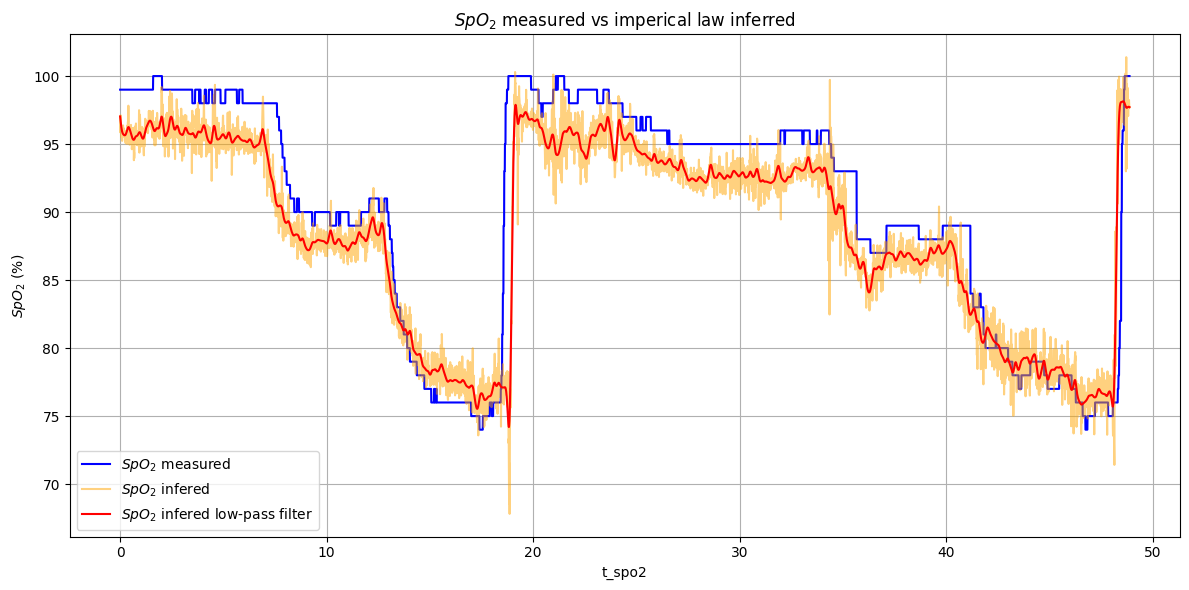

In [11]:
cutoff_hz = 0.05
fs_spo2 = 1/(0.5)

nyq = 0.5 * fs_spo2
normal_cutoff = cutoff_hz / nyq
b, a = butter(N=2, Wn=normal_cutoff, btype='low')

R_lp = filtfilt(b, a, R_resampled)

# Conversion selon la loi empirique
spo2_inferred = 110 - 25 * R_resampled
spo2_inferred_lp = 110 - 25 * R_lp

# Tracé des trois courbes
plt.figure(figsize=(12, 6))
plt.plot(t_spo2, spo2, label="$SpO_{2}$ measured",color='blue')
plt.plot(t_spo2, spo2_inferred, label="$SpO_{2}$ infered", color='orange', alpha=0.5)
plt.plot(t_spo2, spo2_inferred_lp, label="$SpO_{2}$ infered low-pass filter",color='red')
plt.xlabel("t_spo2")
plt.ylabel("$SpO_{2}$ (%)")
plt.title("$SpO_{2}$ measured vs imperical law inferred")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


So we get the inferred curve (`yellow`), to which I've applied a low-pass filter (`red`) to get a better view of the result. We can see that the inferred curve follows the generak trend of the basic signal (`blue`) except that it has a lower $SpO_{2}$ and is also much less stable.

## Part 2: Inference

<div class="alert alert-success">
    
**Exercise**. Write a `generate` function that takes as arguments an array $\text{SpO2}_{1:T}$ of $T$ oxygen saturation measurements (caution, it is expressed in %), along with the 5 parameters ($\sigma^2$, $\epsilon_\text{HbO2}(660nm)$, $\epsilon_\text{Hb}(660nm)$, $\epsilon_\text{HbO2}(940nm)$, $\epsilon_\text{HbO2}(940nm)$), and that returns $n$ realisation of the ratio $R$ for each of the $T$ inputs. You are free to choose any alternate parametrization for the parameters. Display some realisations of the ratios ($R$) for some $\text{SpO2}_{1:T}$ data that you select.

</div>

In [12]:
def generate(spo2_array, params, n):

    sigma = params["sigma"]
    eps660_O2 = params["epsilon_HbO2_660"]
    eps660_Hb = params["epsilon_Hb_660"]
    eps940_O2 = params["epsilon_HbO2_940"]
    eps940_Hb = params["epsilon_Hb_940"]

    spo2_frac = spo2_array / 100.0
    A_660 = spo2_frac*eps660_O2 + (1-spo2_frac) * eps660_Hb
    A_940 = spo2_frac*eps940_O2 + (1-spo2_frac) * eps940_Hb
    R_mean = A_660/A_940

    R_samples = np.random.normal(R_mean[:, None], sigma, size=(len(spo2_frac), n))
    return R_samples


params = {
    "sigma": 0.01,
    "epsilon_HbO2_660": EPS_HBO2_660,
    "epsilon_Hb_660": EPS_HB_660,
    "epsilon_HbO2_940": EPS_HBO2_940,
    "epsilon_Hb_940": EPS_HB_940,
}

spo2_array = spo2[:10]
print("Spo2 values 2:", spo2_array)

print("Actual observations of R:")
print(R_resampled[:10])


R_realizations = generate(spo2_array, params, 1)
print("Generated R realizations shape:")
print( R_realizations)







Spo2 values 2: [99. 99. 99. 99. 99. 99. 99. 99. 99. 99.]
Actual observations of R:
[0.51779128 0.56523979 0.54913453 0.51565506 0.55216314 0.5686867
 0.54758749 0.56929868 0.58053439 0.56055892]
Generated R realizations shape:
[[0.27374986]
 [0.28902405]
 [0.29603238]
 [0.288411  ]
 [0.2888071 ]
 [0.28464845]
 [0.28978961]
 [0.2675172 ]
 [0.28354821]
 [0.28149391]]


We can see the `R` generated from the $SpO_{2}$ given in the data that the results are fairly irregular compared to the observed value. Moreover, they are also relatively far from the values calculated in the first exercises due to the fact that the default parameters given are generic and may not be good for the $SpO_{2}$ we have in our data.

<div class="alert alert-success">

**Exercise.** Write a `log_likelihood` function that takes the same arguments as `generate`, along with a ratio ($R$), and returns the log likelihood of this ratio according to the probabilistic model.

</div>

In [13]:
def log_likelihood(spo2_array, params, R_observed):
    sigma = params["sigma"]
    epsilon_HbO2_660 = params["epsilon_HbO2_660"]
    epsilon_Hb_660 = params["epsilon_Hb_660"]
    epsilon_HbO2_940 = params["epsilon_HbO2_940"]
    epsilon_Hb_940 = params["epsilon_Hb_940"]

    spo2_array = spo2_array/ 100
    A_660 = (spo2_array * epsilon_HbO2_660 + (1 - spo2_array) * epsilon_Hb_660)
    A_940 = (spo2_array * epsilon_HbO2_940 + (1 - spo2_array) * epsilon_Hb_940)
    R_mean = (A_660) /A_940
    
    return - norm.logpdf(R_observed, R_mean, sigma).sum()


<div class="alert alert-success">
    
**Exercise**. For simplicity, subsample only one every 200 ratios ($R$) and one every 200 oxygen saturation ($\text{SpO2}$).
    
</div>

In [14]:

subsampling_factor = 200
spo2_subsampled = spo2[::subsampling_factor]
R_subsampled = R_resampled[::subsampling_factor]


print(f"SpO_{2} size after sub-sampling : {len(spo2_subsampled)}")
print(f"R size after sub-sampling : {len(R_subsampled)}")

SpO_2 size after sub-sampling : 30
R size after sub-sampling : 30


<div class="alert alert-success">

**Exercise.** Using the observed ratios ($R$) and your `log_likelihood` function, infer the oxygen saturation data ($\text{SpO2}$) and the 5 parameters, using the maximum of likelihood estimator (MLE). Choose your parametrization and initial guess wisely. Discuss the results.

</div>

Initial parameters (theta): [5.00000e-01 5.00000e-02 3.19600e+02 3.22656e+03 1.21400e+03 6.93440e+02]
  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -5209.7011089858115
        x: [ 1.000e+00  8.000e-04 ...  7.690e+01  1.000e+02]
      nit: 310
      jac: [-6.770e+02  1.125e+06 ... -1.224e-01 -3.960e+00]
     nfev: 13431
     njev: 363
 hess_inv: <36x36 LbfgsInvHessProduct with dtype=float64>
 $SpO_{2}$ estimés : [ 97.2655634   95.10826125  95.94577901  94.81530314  94.77806783
  89.32154245  87.67709512  88.48215735  83.44337438  78.68212462
  78.80587003  81.65420452  96.632309    96.84874826  96.47567749
  95.24344801  94.74193727  92.6040651   93.61092421  92.02843593
  95.38162068  91.92765248  87.96207131  86.05056251  86.97519364
  81.74939774  80.52908101  79.76601936  76.9035763  100.        ]
Paramètres du modèle ajustés : [ 99. 100.  99.  98.  98.  91.  90.  90.  84.  77.  76.  76.  99.  99.
  98.  96.  95.  95.  95.  

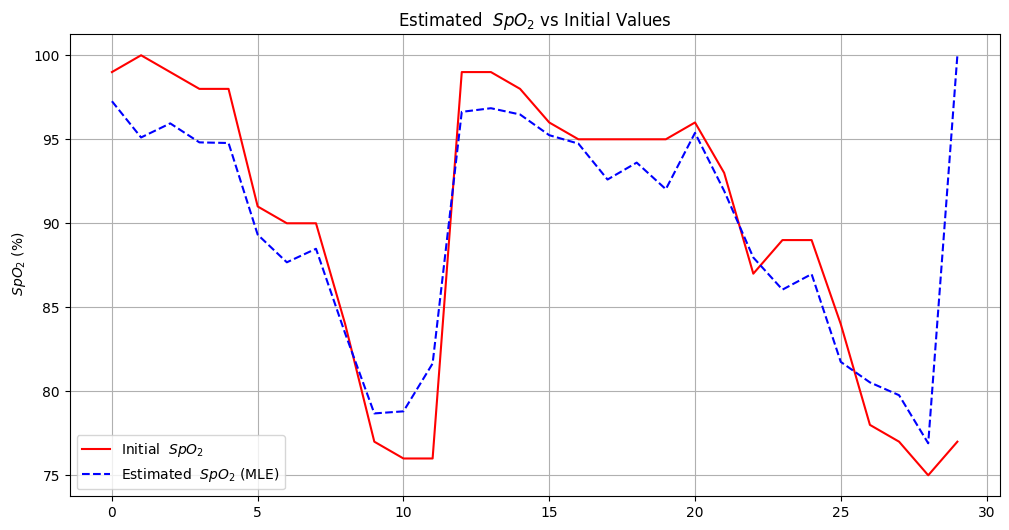

In [15]:
def conbine_log_likelihood(params_array, R_observed, val_spo2):
    sigma,sigmab, epsilon_HbO2_660, epsilon_Hb_660, epsilon_HbO2_940, epsilon_Hb_940 = params_array[:6]
    spo2_estimated = params_array[6:]
    

    params = {
        "sigma": sigmab,
        "epsilon_HbO2_660": epsilon_HbO2_660,
        "epsilon_Hb_660": epsilon_Hb_660,
        "epsilon_HbO2_940": epsilon_HbO2_940,
        "epsilon_Hb_940": epsilon_Hb_940,
    }

    return (log_likelihood(spo2_estimated, params, R_observed) - norm.logpdf(val_spo2, spo2_estimated, sigma)).sum()

n_spo2 = 30


theta_init = np.array([0.5, 0.05,EPS_HBO2_660,EPS_HB_660,EPS_HBO2_940,EPS_HB_940])
print("Initial parameters (theta):", theta_init)


initial_params = np.concatenate(( theta_init, spo2_subsampled ))

bounds = [
    (0.001, 1),
    (0.0008, 1),
    (1, None),
    (1, None),
    (1, None),
    (1, None),
] + [(0, 100)] * n_spo2


res = minimize(
    conbine_log_likelihood,
    x0=initial_params,
    args=(R_subsampled, spo2_subsampled),
    bounds=bounds
)

print(res)
fitted_params = res.x
spo2_estimated = fitted_params[6:]
fitted_model_params = fitted_params[:6]

print(" $SpO_{2}$ estimés :", spo2_estimated)
print("Paramètres du modèle ajustés :", spo2_subsampled)
print("Paramètres du modèle :", fitted_model_params)

plt.figure(figsize=(12, 6))
plt.plot(spo2_subsampled, label="Initial  $SpO_{2}$", linestyle="-", color="red")
plt.plot(spo2_estimated, label="Estimated  $SpO_{2}$ (MLE)", linestyle="--", color="blue")
plt.legend()
plt.xlabel("")
plt.ylabel(" $SpO_{2}$ (%)")
plt.title("Estimated  $SpO_{2}$ vs Initial Values")
plt.grid(True)
plt.show()

We can see that the results are relatively far from the values indicated in the data.
It is possible to obtain exactly the same $SpO_{2}$ value as that indicated in the data by increasing the sigma in the second likelihood calculation (``sigma``), but the other parameters are so approximate that it becomes impossible to calculate the ratio using the ``generate`` function in the following exercise.

<div class="alert alert-success">
    
**Exercise**. Plot the distribution of ratios from the fitted model throughout the subsampled time series and compare it to the observed ratios. Then, ignore the temporal aspect and display the marginal distributions of ratios from the fitted model, along with the marginal observed distribution of ratios. Discuss the results.
        
</div>

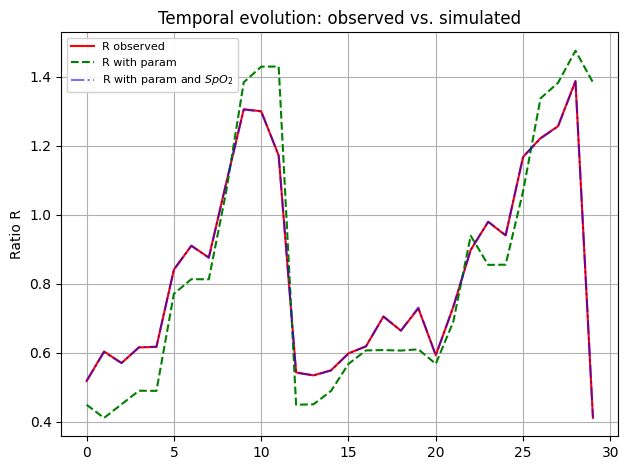

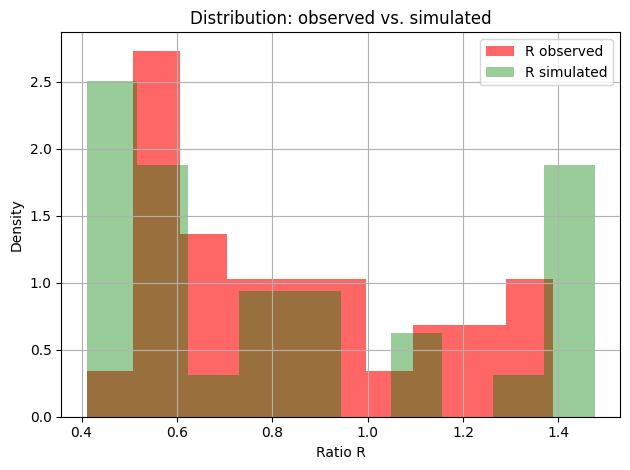

In [16]:

params_hat = {
    "sigma": fitted_model_params[1],
    "epsilon_HbO2_660":fitted_model_params[2],
    "epsilon_Hb_660": fitted_model_params[3],
    "epsilon_HbO2_940": fitted_model_params[4],
    "epsilon_Hb_940": fitted_model_params[5],
}


R_sims = generate(spo2_subsampled, params_hat, 1)
R_all = generate(spo2_estimated, params_hat, 1)

plt.plot(R_subsampled,label="R observed", color="red")
plt.plot(R_sims,label="R with param", linestyle="--", color="green")
plt.plot(R_all,label="R with param and $SpO_{2}$", linestyle="-.", color="blue", alpha=0.55)
plt.xlabel("")
plt.ylabel("Ratio R")
plt.title("Temporal evolution: observed vs. simulated")
plt.legend(loc="upper left", fontsize=8, frameon=True,framealpha=0.9)
plt.grid(True)
plt.tight_layout()
plt.show()




plt.hist(R_subsampled, bins=10, density=True, alpha=0.6, label="R observed",  color="red")
plt.hist(R_sims, bins=10, density=True, alpha=0.4, label="R simulated", color="green")
#plt.hist(R_all, bins=10, density=True, alpha=0.4, label="R simulé all", color="green")
plt.xlabel("Ratio R")
plt.ylabel("Density")
plt.title("Distribution: observed vs. simulated")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


We calculate the ratio with the `generate` function or we apply the parameters and $SpO_{2}$ calculated previously. An improvement is then observed between the ``R``'s calculated with `generate`.

On the first plot we can see that the observed R (`red`) and the R simulated with the $SpO_{2}$ and the parameters (`blue`) calculated in the previous exercise are almost the same, if not identical. The $SpO_{2}$ and the parmetres were both adjusted to get the best approximation of the R's.

As for the R calculated only with the parmeters (`green`), they are relatively close to the observed R values.

For the second plot, as the observed R (`red`) and simulated R (`blue`) are exactly the same, there is no need to plot both of them.
We can see that the simulated R (`green`) tends to underestimate the ratio. It's just at the end that we overestimate.

<div class="alert alert-success">
    
**Exercise**. Finally, plot the SpO2 values infered by MLE, together with the SpO2 values infered by the empirical model, and compare it to the SpO2 measurements. Give your observations, compare the results obtained by the two models, and discuss their limitations.
        
</div>

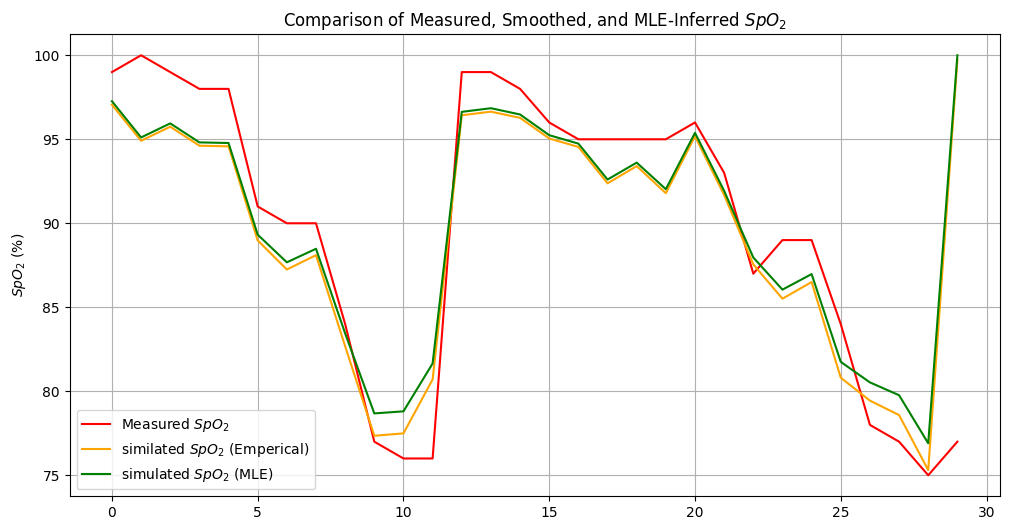

In [17]:

t_subsampled = t_spo2[::subsampling_factor]
spo2_inferred = 110 - 25 * R_subsampled

plt.figure(figsize=(12, 6))

plt.plot( spo2_subsampled, label="Measured $SpO_{2}$", color='red')
plt.plot( spo2_inferred, label="similated $SpO_{2}$ (Emperical)", color='orange')
plt.plot( spo2_estimated, label="simulated $SpO_{2}$ (MLE)", color='green')

plt.xlabel("")
plt.ylabel("$SpO_{2}$ (%)")
plt.title("Comparison of Measured, Smoothed, and MLE-Inferred $SpO_{2}$")
plt.legend()
plt.grid(True)
plt.show()

We can see that the MLE simulation curve (`green`) is slightly better than the empirical curve (`orange').  We could improve the $SpO_{2}$ simulation at the expense of the ratio.

The big problem with the MLE simulation is that it's a bit of a one-size-fits-all, given the results I've had. It's complicated to find the parameters that will give good results on everything.